In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb 
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_data=pd.read_csv('train_data.csv')
train_data

,loan_id,origination_date,maturity_date,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,...,Telecom,Utilities,bond,lease,mortgage,revolving,term_loan,partially_secured,secured,unsecured
0,L008633,2015-01-01,2016-01-01,0.000000,Consumer,term_loan,unsecured,0.714286,0.700000,-0.289402,...,0,0,0,0,0,0,1,0,0,1
1,L009184,2015-01-01,2016-01-01,0.000000,Industrials,bond,unsecured,1.000000,0.805455,-0.377311,...,0,0,1,0,0,0,0,0,0,1
2,L010332,2015-01-01,2016-01-01,0.000000,Retail,lease,secured,0.714286,0.794545,0.814112,...,0,0,0,1,0,0,0,0,1,0
3,L011575,2015-01-01,2016-01-01,0.000000,Real_Estate,revolving,partially_secured,0.571429,0.934545,-0.091036,...,0,0,0,0,0,1,0,1,0,0
4,L014402,2015-01-01,2016-01-01,0.000000,Energy,bond,partially_secured,0.571429,0.838182,-0.063589,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,L015462,2021-04-01,2024-12-31,0.444444,Consumer,mortgage,secured,0.571429,0.674545,-0.464890,...,0,0,0,0,1,0,0,0,1,0
34996,L015508,2021-04-01,2024-12-31,0.333333,Utilities,mortgage,unsecured,0.428571,0.821818,-0.155166,...,0,1,0,0,1,0,0,0,0,1
34997,L015595,2021-04-01,2024-12-31,1.000000,Technology,revolving,unsecured,0.571429,0.803636,-0.238896,...,0,0,0,0,0,1,0,0,0,1
34998,L015659,2021-04-01,2024-12-31,0.666667,Real_Estate,term_loan,secured,0.857143,0.838182,-0.228936,...,0,0,0,0,0,0,1,0,1,0


In [3]:
test_data=pd.read_csv('test_data.csv')
test_data

,loan_id,origination_date,maturity_date,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,...,Telecom,Utilities,bond,lease,mortgage,revolving,term_loan,partially_secured,secured,unsecured
0,L016040,2021-04-01,2024-12-31,0.333333,Energy,bond,partially_secured,0.142857,0.687273,-0.426455,...,0,0,1,0,0,0,0,1,0,0
1,L016223,2021-04-01,2024-12-31,0.444444,Financials,revolving,partially_secured,0.285714,0.807273,-0.349716,...,0,0,0,0,0,1,0,1,0,0
2,L016308,2021-04-01,2024-12-31,1.000000,Retail,term_loan,unsecured,0.428571,0.647273,0.079292,...,0,0,0,0,0,0,1,0,0,1
3,L016659,2021-04-01,2024-12-31,0.444444,Industrials,mortgage,secured,0.285714,0.601818,-0.382590,...,0,0,0,0,1,0,0,0,1,0
4,L016683,2021-04-01,2024-12-31,1.000000,Real_Estate,term_loan,unsecured,0.428571,0.707273,1.054665,...,0,0,0,0,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,L049222,2023-12-01,2024-12-31,0.666667,Financials,mortgage,partially_secured,0.571429,0.740000,-0.435100,...,0,0,0,0,1,0,0,1,0,0
14996,L049376,2023-12-01,2024-12-31,1.000000,Telecom,mortgage,secured,0.571429,0.763636,-0.385395,...,1,0,0,0,1,0,0,0,1,0
14997,L049468,2023-12-01,2024-12-31,0.666667,Energy,term_loan,unsecured,0.428571,0.758182,-0.064488,...,0,0,0,0,0,0,1,0,0,1
14998,L049469,2023-12-01,2024-12-31,1.000000,Retail,lease,secured,0.857143,0.910909,-0.259069,...,0,0,0,1,0,0,0,0,1,0


In [4]:
train_stat=pd.read_csv('train_stat.csv')
train_stat

,origination_date,maturity_date,maturity_months,credit_score,ead,coupon_rate,leverage,interest_coverage,debt_to_equity,pd_annual,lgd,el,unexpected_loss,rwa,defaulted,default_date,survival_months,recovery_rate,loss_given_default
0,35000,35000,35000.000000,35000.000000,3.500000e+04,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,3.500000e+04,3.500000e+04,3.500000e+04,35000.000000,5753,35000.000000,5753.000000,5.753000e+03
1,2018-02-06 08:17:54.651428608,2022-03-26 11:27:34.765714176,54.014743,715.089686,3.308804e+06,2.931451,6.904236,3.763323,2.086235,0.022912,0.546819,4.007181e+04,1.850387e+05,5.309515e+05,0.164371,2020-06-15 02:17:10.001738240,48.303371,0.455569,1.753435e+06
2,2015-01-01 00:00:00,2016-01-01 00:00:00,12.000000,518.000000,5.000000e+04,1.000000,0.500000,0.500000,0.100000,0.000158,0.091800,3.600000e+00,2.735300e+02,4.765000e+01,0.000000,2015-02-01 00:00:00,1.000000,0.020000,1.433000e+04
3,2016-07-01 00:00:00,2020-07-01 00:00:00,36.000000,679.000000,5.504071e+05,2.483000,4.050000,2.370000,1.030000,0.001295,0.443400,7.984225e+02,1.739675e+04,1.057908e+04,0.000000,2020-04-01 00:00:00,35.000000,0.353700,2.899526e+05
4,2018-02-01 00:00:00,2022-06-01 00:00:00,48.000000,715.000000,1.396801e+06,3.010000,6.080000,3.310000,1.650000,0.002806,0.544900,3.631560e+03,5.260387e+04,4.811816e+04,0.000000,2020-05-01 00:00:00,48.000000,0.455700,7.219356e+05
5,2019-09-01 00:00:00,2024-05-01 00:00:00,60.000000,750.000000,3.424126e+06,3.458000,9.050000,4.650000,2.630000,0.016640,0.647400,1.893992e+04,1.579063e+05,2.509540e+05,0.000000,2020-06-01 00:00:00,60.000000,0.561500,1.766335e+06
6,2021-04-01 00:00:00,2024-12-31 00:00:00,120.000000,850.000000,3.611778e+08,5.896000,15.000000,20.000000,10.000000,0.242523,0.980000,6.411410e+06,2.239212e+07,8.495118e+07,1.000000,2030-12-01 00:00:00,120.000000,0.854500,1.113264e+08
7,NaN,NaN,26.719180,50.841787,6.723379e+06,0.819725,3.683419,2.009622,1.564232,0.041357,0.144888,1.686148e+05,5.162670e+05,2.234146e+06,0.370618,NaN,26.877033,0.145196,3.807581e+06


In [5]:
sector_col=['Energy', 'Telecom', 'Consumer', 'Financials', 'Industrials', 'Healthcare', 'Technology', 'Utilities', 'Retail', 'Real_Estate']
loan_type_col=['term_loan', 'mortgage', 'revolving', 'bond', 'lease']
collateral_col=['secured', 'unsecured', 'partially_secured']

dummy_backward=[sector_col, loan_type_col, collateral_col]

#catagorize feature column
input_col=['maturity_months','initial_rating','credit_score','ead','coupon_rate','leverage','interest_coverage','debt_to_equity']+sum(dummy_backward,[])  #dummy_col
cal_input_col=['pd_annual','lgd','el','unexpected_loss','rwa']
output_col=['defaulted','survival_months']
cal_output_col=['recovery_rate','loss_given_default']

input_all=input_col+cal_input_col
output_all=output_col+cal_output_col

# Logistic Regression

## Using all input feature

In [6]:
xgb_model2 = xgb.XGBClassifier()
xgb_model2.fit(train_data[input_all],train_data['defaulted']) #exclude calculated columns

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [7]:
train_predict2=xgb_model2.predict(train_data[input_all])
xgb_model2.score(train_data[input_all],train_data['defaulted'])

0.8962571428571429

In [8]:
test_predict2=xgb_model2.predict(test_data[input_all])
xgb_model2.score(test_data[input_all],test_data['defaulted'])

0.9162

Text(0.5, 1.0, 'Feature Importance (Gain)')

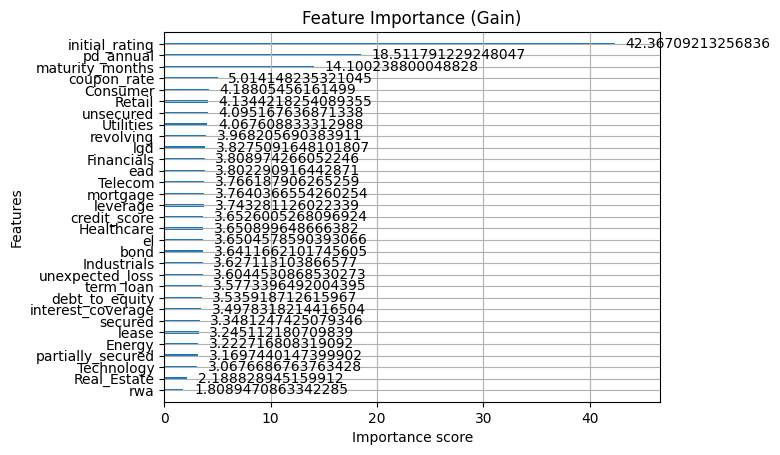

In [9]:
xgb.plot_importance(xgb_model2, importance_type='gain') #how much it reduce cost
plt.title('Feature Importance (Gain)')

# Evaluation

In [10]:
booster = xgb_model2.get_booster()
gain_dict = booster.get_score(importance_type='gain')
gain_dict

{'maturity_months': 14.100238800048828,
 'initial_rating': 42.36709213256836,
 'credit_score': 3.6526005268096924,
 'ead': 3.802290916442871,
 'coupon_rate': 5.014148235321045,
 'leverage': 3.743281126022339,
 'interest_coverage': 3.4978318214416504,
 'debt_to_equity': 3.535918712615967,
 'Energy': 3.222716808319092,
 'Telecom': 3.766187906265259,
 'Consumer': 4.18805456161499,
 'Financials': 3.808974266052246,
 'Industrials': 3.627113103866577,
 'Healthcare': 3.650899648666382,
 'Technology': 3.0676686763763428,
 'Utilities': 4.067608833312988,
 'Retail': 4.1344218254089355,
 'Real_Estate': 2.188828945159912,
 'term_loan': 3.5773396492004395,
 'mortgage': 3.7640366554260254,
 'revolving': 3.968205690383911,
 'bond': 3.6411662101745605,
 'lease': 3.245112180709839,
 'secured': 3.3481247425079346,
 'unsecured': 4.095167636871338,
 'partially_secured': 3.1697440147399902,
 'pd_annual': 18.511791229248047,
 'lgd': 3.8275091648101807,
 'el': 3.6504578590393066,
 'unexpected_loss': 3.604453

In [11]:
sort_idx=np.argsort(list(gain_dict.values()))
sort_idx

array([30, 17, 14, 25,  8, 22, 23,  6,  7, 18, 29, 12, 21, 28, 13,  2,  5,
       19,  9,  3, 11, 27, 20, 15, 24, 16, 10,  4,  0, 26,  1])

In [12]:
dom_input = [ input_all[i] for i in sort_idx[::-1]]
dom_input

['initial_rating',
 'pd_annual',
 'maturity_months',
 'coupon_rate',
 'Consumer',
 'Retail',
 'unsecured',
 'Utilities',
 'revolving',
 'lgd',
 'Financials',
 'ead',
 'Telecom',
 'mortgage',
 'leverage',
 'credit_score',
 'Healthcare',
 'el',
 'bond',
 'Industrials',
 'unexpected_loss',
 'term_loan',
 'debt_to_equity',
 'interest_coverage',
 'secured',
 'lease',
 'Energy',
 'partially_secured',
 'Technology',
 'Real_Estate',
 'rwa']

In [13]:
dom_input = [ input_all[i] for i in sort_idx[::-1]]
dom_input

['initial_rating',
 'pd_annual',
 'maturity_months',
 'coupon_rate',
 'Consumer',
 'Retail',
 'unsecured',
 'Utilities',
 'revolving',
 'lgd',
 'Financials',
 'ead',
 'Telecom',
 'mortgage',
 'leverage',
 'credit_score',
 'Healthcare',
 'el',
 'bond',
 'Industrials',
 'unexpected_loss',
 'term_loan',
 'debt_to_equity',
 'interest_coverage',
 'secured',
 'lease',
 'Energy',
 'partially_secured',
 'Technology',
 'Real_Estate',
 'rwa']

In [14]:
N = len(dom_input)
all_model = []
train_cost = []
test_cost = []

train_f1 = []
test_f1 = []

train_p = []
test_p = []

train_r = []
test_r = []

for i in range(N):
    dom_input_temp = dom_input[:N-i]

    xgb_model_temp = xgb.XGBClassifier()
    xgb_model_temp.fit(train_data[dom_input_temp],train_data['defaulted'])
    all_model.append(xgb_model_temp)

    train_predict_temp=xgb_model_temp.predict(train_data[dom_input_temp])
    train_cost.append( xgb_model_temp.score(train_data[dom_input_temp],train_data['defaulted']) )

    test_predict_temp=xgb_model_temp.predict(test_data[dom_input_temp])
    test_cost.append( xgb_model_temp.score(test_data[dom_input_temp],test_data['defaulted']) )

    train_confM=confusion_matrix(train_data['defaulted'],train_predict_temp)
    train_f1.append(2*train_confM[1,1]/(2*train_confM[1,1]+train_confM[1,0]+train_confM[0,1]))
    train_p.append(train_confM[1,1]/(train_confM[1,1]+train_confM[0,1]))
    train_r.append(train_confM[1,1]/(train_confM[1,1]+train_confM[1,0]))
    
    test_confM=confusion_matrix(test_data['defaulted'],test_predict_temp)
    test_f1.append(2*test_confM[1,1]/(2*test_confM[1,1]+test_confM[1,0]+test_confM[0,1]))
    test_p.append(test_confM[1,1]/(test_confM[1,1]+test_confM[0,1]))
    test_r.append(test_confM[1,1]/(test_confM[1,1]+test_confM[1,0]))

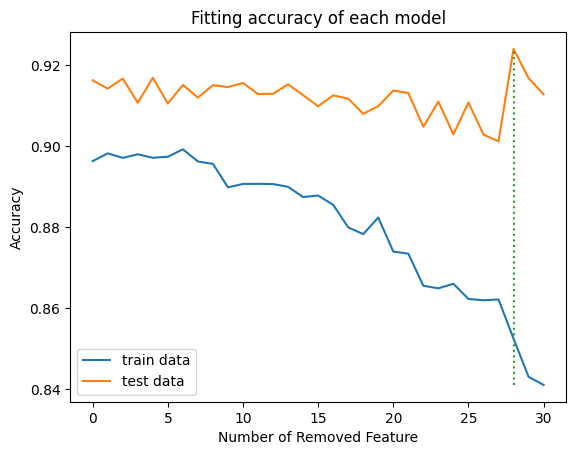

In [15]:
plt.figure()
plt.plot(train_cost, label='train data')
plt.plot(test_cost, label='test data')
plt.plot([28,28],[np.min(train_cost), np.max(test_cost)], linestyle=':')
plt.title('Fitting accuracy of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [16]:
test_cost[20:]

[0.9136666666666666,
 0.9130666666666667,
 0.9047333333333333,
 0.9109333333333334,
 0.9028666666666667,
 0.9107333333333333,
 0.9028,
 0.9011333333333333,
 0.9239333333333334,
 0.9167333333333333,
 0.9127333333333333]

In [17]:
dom_input[:N-20] # conclusion : all we need is initial_rating, pd_annual, maturity_months, coupon_rate

['initial_rating',
 'pd_annual',
 'maturity_months',
 'coupon_rate',
 'Consumer',
 'Retail',
 'unsecured',
 'Utilities',
 'revolving',
 'lgd',
 'Financials']

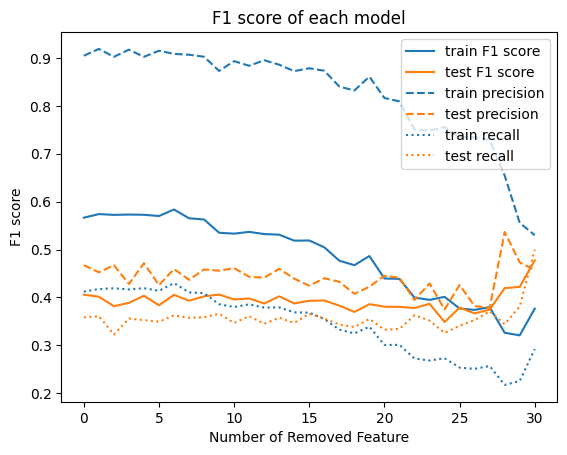

In [18]:
plt.figure()
plt.plot(train_f1, label='train F1 score', c='C0')
plt.plot(test_f1, label='test F1 score', c='C1')
plt.plot(train_p, label='train precision', c='C0', linestyle='--')
plt.plot(test_p, label='test precision', c='C1', linestyle='--')
plt.plot(train_r, label='train recall', c='C0', linestyle=':')
plt.plot(test_r, label='test recall', c='C1', linestyle=':')
#plt.plot([22,22],[np.min(train_f1), np.max(test_f1)], linestyle=':', c='C2')
#plt.plot([22,22],[0.2, 0.9], linestyle=':', c='C2')
plt.title('F1 score of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('F1 score')
plt.legend()
plt.show()

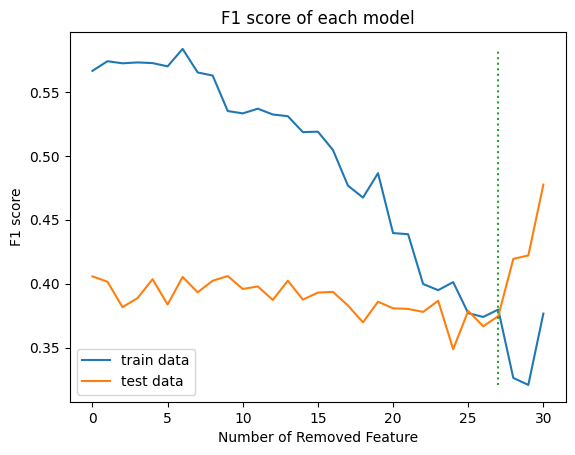

In [19]:
plt.figure()
plt.plot(train_f1, label='train data')
plt.plot(test_f1, label='test data')
plt.plot([27,27],[np.min(train_f1), np.max(train_f1)], linestyle=':')
plt.title('F1 score of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('F1 score')
plt.legend()
plt.show()

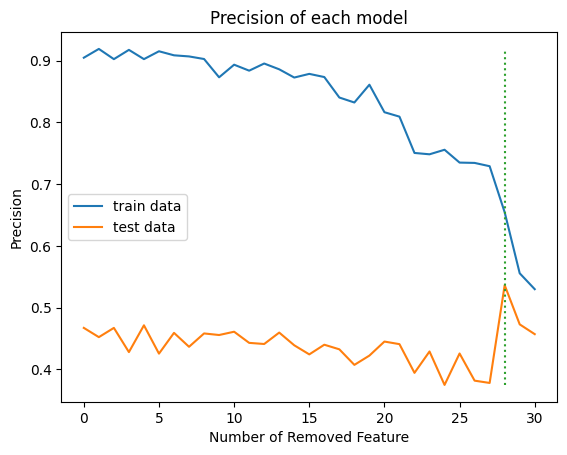

In [20]:
plt.figure()
plt.plot(train_p, label='train data')
plt.plot(test_p, label='test data')
plt.plot([28,28],[np.min(test_p), np.max(train_p)], linestyle=':')
plt.title('Precision of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Precision')
plt.legend()
plt.show()

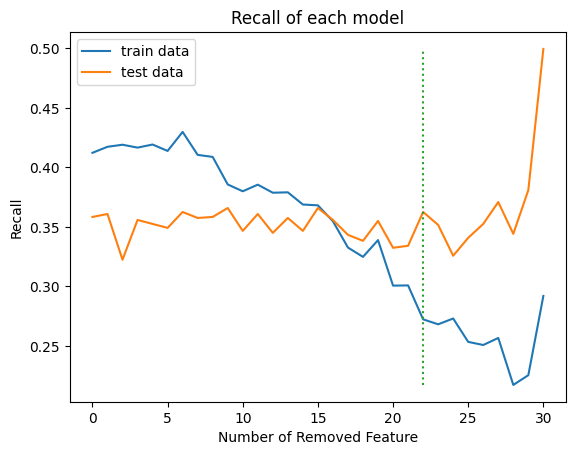

In [21]:
plt.figure()
plt.plot(train_r, label='train data')
plt.plot(test_r, label='test data')
plt.plot([22,22],[np.min(train_r), np.max(test_r)], linestyle=':')
plt.title('Recall of each model')
plt.xlabel('Number of Removed Feature')
plt.ylabel('Recall')
plt.legend()
plt.show()

In [98]:
display(np.max(test_p))
display(np.argmax(test_p))

display(np.max(test_r))
display(np.argmax(test_r))

display(np.max(test_f1))
display(np.argmax(test_f1))

np.float64(0.5364583333333334)

np.int64(28)

np.float64(0.49958228905597324)

np.int64(30)

np.float64(0.47744510978043914)

np.int64(30)

In [99]:
display(np.array(test_p[20:]))
display(np.array(test_r[20:]))
display(np.array(test_f1[20:]))

array([0.44519016, 0.44101433, 0.39454545, 0.42915392, 0.375     ,
       0.42588727, 0.38190045, 0.37819421, 0.53645833, 0.47302905,
       0.45718654])

array([0.33249791, 0.33416876, 0.3625731 , 0.35171261, 0.32581454,
       0.34085213, 0.35254804, 0.37092732, 0.34419382, 0.38095238,
       0.49958229])

array([0.3806791 , 0.38022814, 0.3778842 , 0.3865932 , 0.34868127,
       0.37865429, 0.36663771, 0.37452552, 0.41933842, 0.42202684,
       0.47744511])

# Plot Feature

In [35]:
dom_input2 = ['maturity_months', 'initial_rating', 'credit_score']
train_data2 = train_data.copy()

In [36]:
train_data2['maturity_months0']=(train_data2['maturity_months']*(120-12)+12).astype('int')
train_maturity_months=train_data2['maturity_months0'].value_counts().sort_index()
train_maturity_months

maturity_months0
12     1720
24     3441
36     6921
48     8828
60     7121
84     4143
120    2826
Name: count, dtype: int64

In [49]:
train_maturity_months.index

Index([12, 24, 36, 48, 60, 84, 120], dtype='int64', name='maturity_months0')

In [37]:
# transform initial rating as number 0-1 to string
def num_to_rate(num):
    temp=np.round(num*7)
    if temp==7: return'AAA'
    elif temp==6: return 'AA'
    elif temp==5: return 'A'
    elif temp==4: return 'BBB'
    elif temp==3: return 'BB'
    elif temp==2: return 'B'
    elif temp==1: return 'CCC'
    else: return 'D'

train_data2['initial_rating0']=train_data2['initial_rating'].apply(num_to_rate)
train_initial_rating=train_data2['initial_rating0'].value_counts().sort_index()
train_initial_rating

initial_rating0
A      5267
AA     2799
AAA    1050
B      5266
BB     7692
BBB    9756
CCC    3170
Name: count, dtype: int64

In [38]:
train_data2['credit_score0']=(train_data2['credit_score']*(850-300)+300).astype('int')
train_credit_score=train_data2['credit_score0'].value_counts().sort_index()
train_credit_score

credit_score0
518      1
534      1
539      1
540      1
541      1
      ... 
845     13
846     20
848      9
849     11
850    139
Name: count, Length: 299, dtype: int64

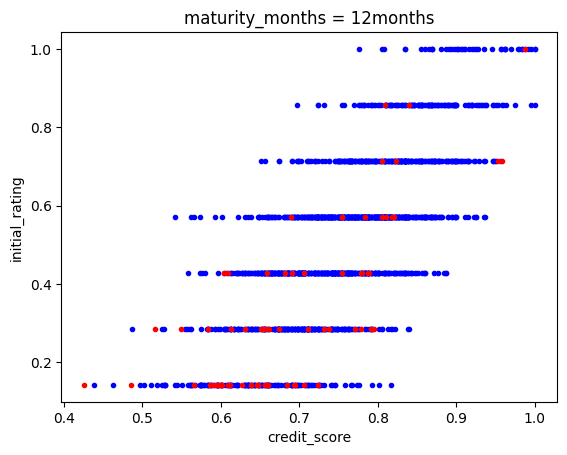

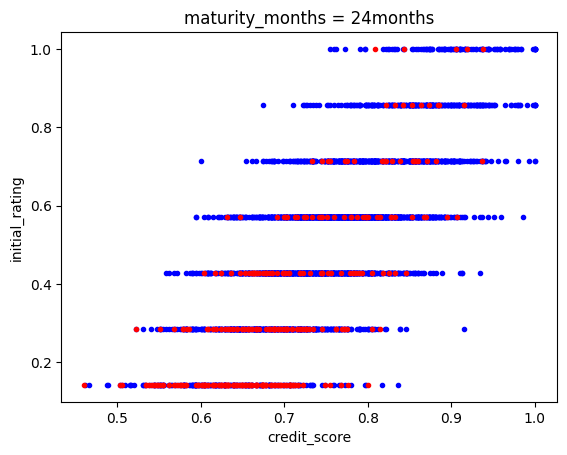

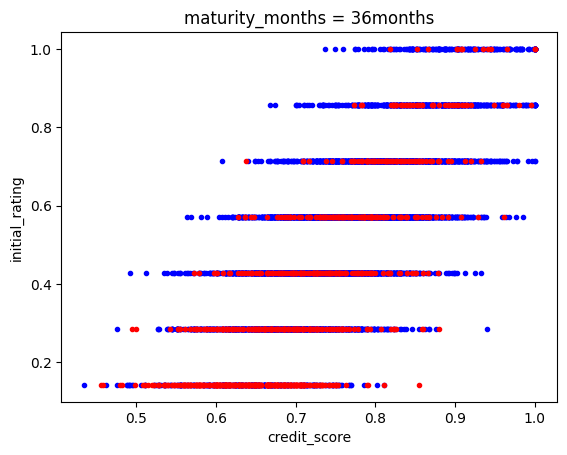

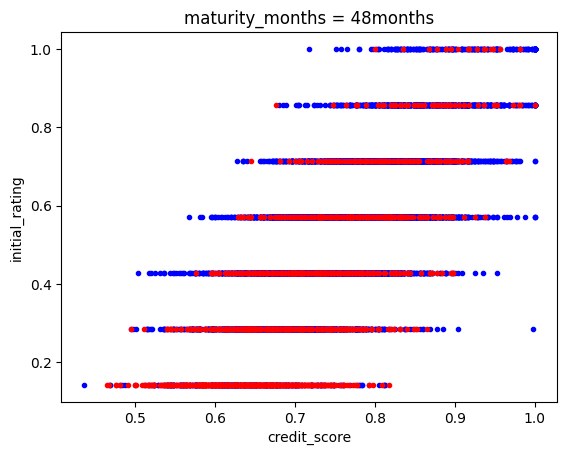

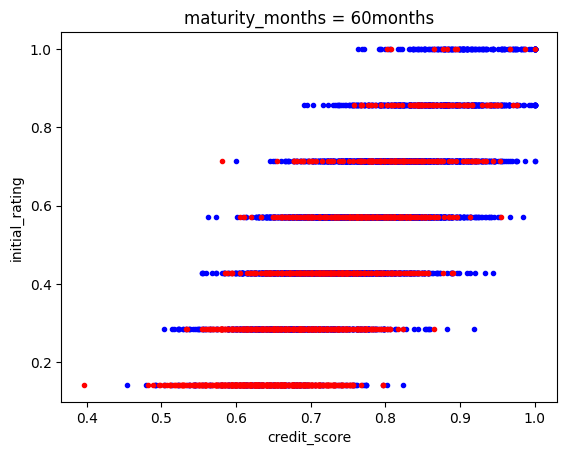

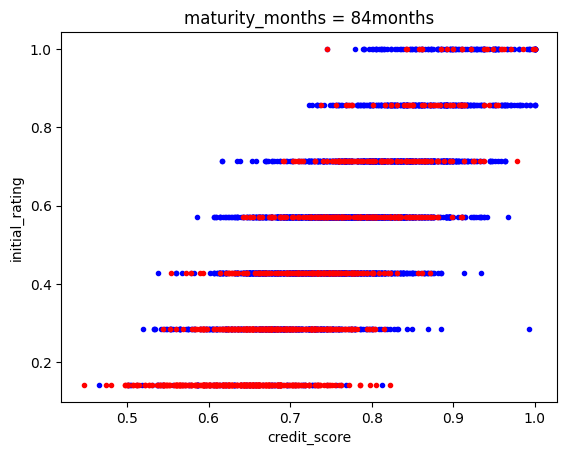

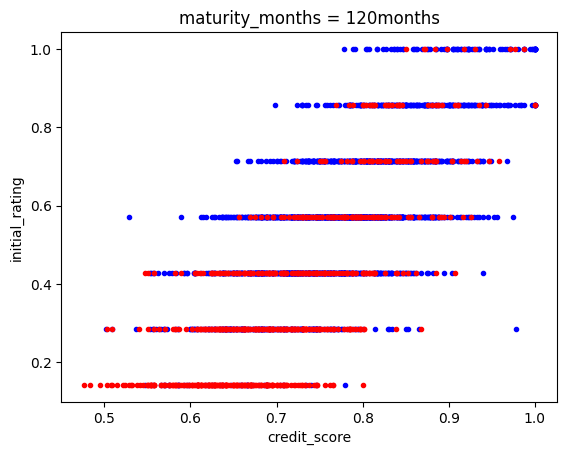

In [60]:
for mm in train_maturity_months.index:
    plt.figure()

    train_temp1=train_data2[ (train_data2['maturity_months0']==mm) & (train_data2['defaulted']==0) ]
    plt.scatter(train_temp1['credit_score'],train_temp1['initial_rating'], c='b', marker='.')

    train_temp2=train_data2[ (train_data2['maturity_months0']==mm) & (train_data2['defaulted']==1) ]
    plt.scatter(train_temp2['credit_score'],train_temp2['initial_rating'], c='r', marker='.')

    plt.xlabel('credit_score')
    plt.ylabel('initial_rating')
    plt.title('maturity_months = '+str(mm)+ 'months')
    plt.show()

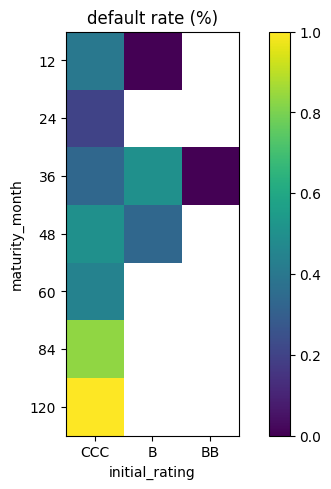

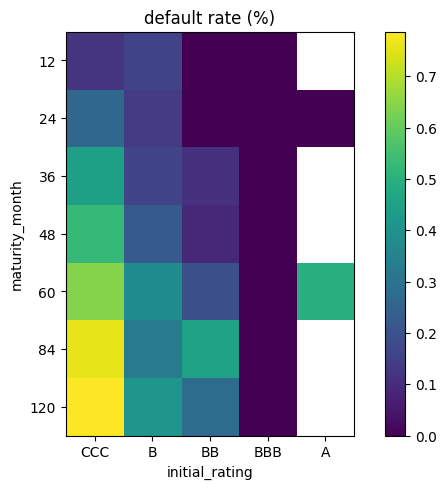

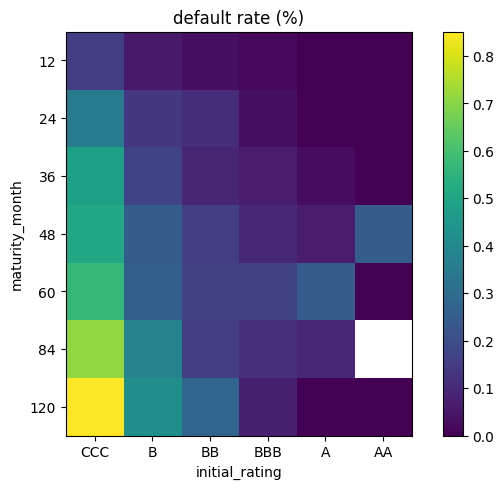

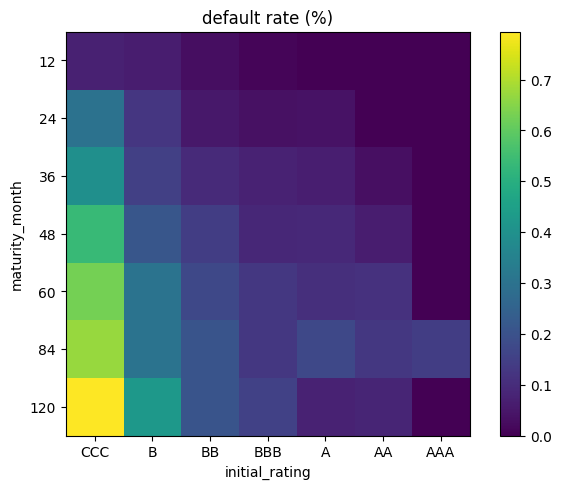

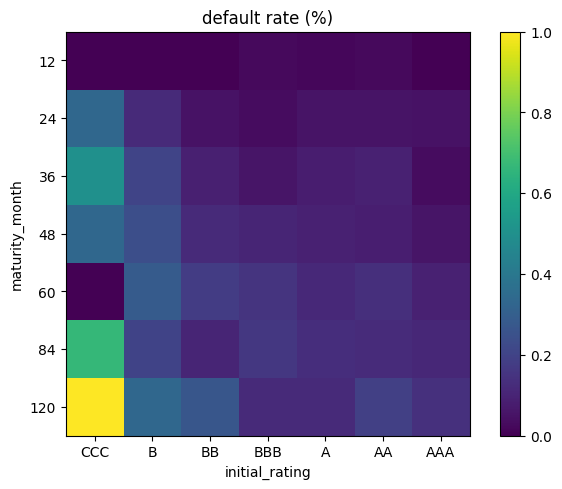

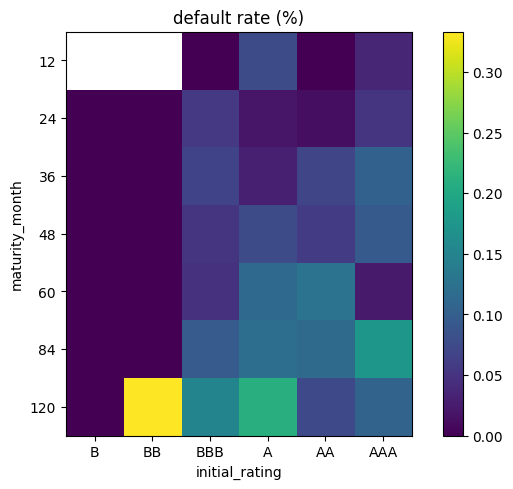

In [95]:
for k in range(4,10):

    train_temp=train_data2[ (train_data2['credit_score']>=0.1*k) & (train_data2['credit_score']<0.1*(k+1)) ]

    train_count=train_temp.groupby(['maturity_months','initial_rating'])[['defaulted']].agg('count').reset_index()
    train_count2=pd.pivot_table(train_count, index='maturity_months', columns='initial_rating')

    train_def=train_temp.groupby(['maturity_months','initial_rating'])[['defaulted']].agg('sum').reset_index()
    train_def2=pd.pivot_table(train_def, index='maturity_months', columns='initial_rating')

    default_table=train_def2/train_count2

    fig, ax = plt.subplots()
    im = ax.imshow(default_table)

    ax.set_yticks(range(len(default_table.index)), labels=[int(i*(120-12)+12)  for i in default_table.index ] ) #rotation_mode="xtick"
    ax.set_xticks(range(len(default_table.keys())), labels=[num_to_rate(i[1]) for i in default_table.keys()])

    default_label=np.round(default_table*100,1)
    # Loop over data dimensions and create text annotations.
    #for i in range(7):
        #for j in range(6):
            #text = ax.text(j, i, default_label[i, j], ha="center", va="center") #, color="w"

    ax.set_title('default rate (%)')
    fig.tight_layout()
    plt.colorbar(im,)
    plt.ylabel('maturity_month')
    plt.xlabel('initial_rating')
    plt.show()

In [90]:
k=4

train_temp=train_data2[ (train_data2['credit_score']>=0.1*k) & (train_data2['credit_score']<0.1*(k+1)) ]

train_count=train_temp.groupby(['maturity_months','initial_rating'])[['defaulted']].agg('count').reset_index()
train_count2=pd.pivot_table(train_count, index='maturity_months', columns='initial_rating')

train_def=train_temp.groupby(['maturity_months','initial_rating'])[['defaulted']].agg('sum').reset_index()
train_def2=pd.pivot_table(train_def, index='maturity_months', columns='initial_rating')

default_table=train_def2/train_count2

In [91]:
train_temp

,loan_id,origination_date,maturity_date,maturity_months,sector,loan_type,collateral,initial_rating,credit_score,ead,...,lease,mortgage,revolving,term_loan,partially_secured,secured,unsecured,maturity_months0,initial_rating0,credit_score0
864,L004183,2015-02-01,2022-02-01,0.666667,Real_Estate,term_loan,secured,0.142857,0.465455,0.249527,...,0,0,0,1,0,1,0,84,CCC,556
1589,L007075,2015-04-01,2019-04-01,0.333333,Financials,revolving,partially_secured,0.285714,0.498182,-0.431995,...,0,0,1,0,1,0,0,48,B,574
2901,L044099,2015-07-01,2017-07-01,0.111111,Financials,mortgage,secured,0.142857,0.461818,-0.102745,...,0,1,0,0,0,1,0,24,CCC,554
3625,L015137,2015-08-01,2020-08-01,0.444444,Real_Estate,revolving,unsecured,0.142857,0.454545,0.911462,...,0,0,1,0,0,0,1,60,CCC,550
3836,L000279,2015-09-01,2018-09-01,0.222222,Consumer,term_loan,secured,0.142857,0.496364,-0.484697,...,0,0,0,1,0,1,0,36,CCC,573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32465,L012519,2020-11-01,2022-11-01,0.111111,Retail,revolving,secured,0.142857,0.465455,-0.405164,...,0,0,1,0,0,1,0,24,CCC,556
32742,L007207,2020-11-01,2024-12-31,0.444444,Healthcare,term_loan,unsecured,0.142857,0.490909,-0.036698,...,0,0,0,1,0,0,1,60,CCC,570
33042,L036262,2020-12-01,2023-12-01,0.222222,Financials,bond,partially_secured,0.142857,0.490909,0.003451,...,0,0,0,0,1,0,0,36,CCC,570
33943,L025303,2021-02-01,2024-02-01,0.222222,Real_Estate,term_loan,secured,0.142857,0.480000,-0.040617,...,0,0,0,1,0,1,0,36,CCC,564


In [92]:
default_table

defaulted                   
initial_rating   0.142857  0.285714 0.428571
maturity_months                             
0.000000         0.400000  0.000000      NaN
0.111111         0.200000       NaN      NaN
0.222222         0.333333  0.500000      0.0
0.333333         0.500000  0.333333      NaN
0.444444         0.444444       NaN      NaN
0.666667         0.833333       NaN      NaN
1.000000         1.000000       NaN      NaN